<a href="https://colab.research.google.com/github/khushiravtode/College-ERP/blob/main/Online_Retail_customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

# Get uploaded file name
file = list(uploaded.keys())[0]

# Read Excel or CSV file
df = pd.read_excel(file) if file.endswith(".xlsx") else pd.read_csv(file)

print("Dataset Shape:", df.shape)
df.head()

Saving Online Retail.xlsx to Online Retail (2).xlsx
Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


##Data Preprocessing

In [ ]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

# Remove duplicate records
df = df.drop_duplicates()

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only valid quantity and price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (392692, 9)


##Feature Engineering

In [ ]:
# Calculate total amount spent in each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


##Create RFM Features

In [ ]:
# Reference date = day after the last transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create customer-level RFM data
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                    # Frequency
    "TotalAmount": "sum"                                       # Monetary
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

print("RFM Data:")
rfm.head()

RFM Data:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


##Statistical Analysis


In [ ]:
# Statistical summary of RFM features
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


##RFM Visualization

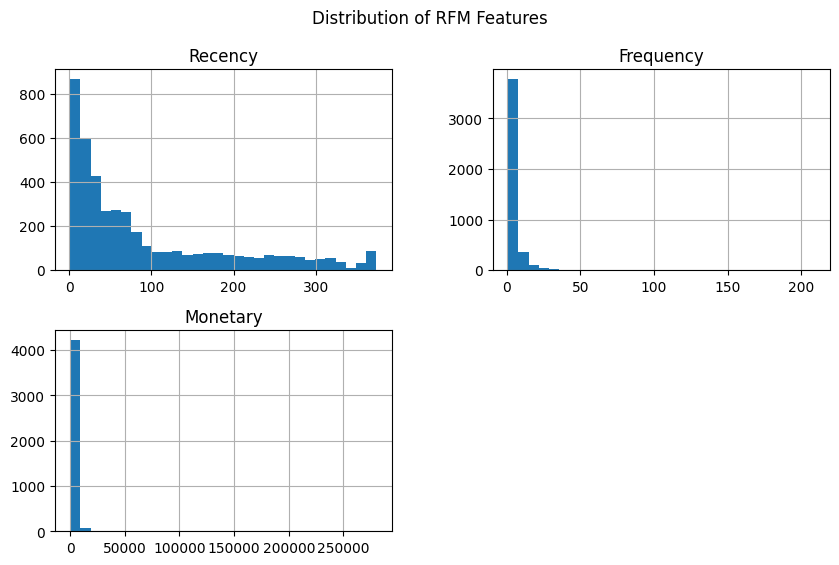

In [ ]:
# Visualize RFM distributions
rfm.hist(figsize=(10, 6), bins=30)

plt.suptitle("Distribution of RFM Features")
plt.show()

##Scale the Features

In [ ]:
# Standardize RFM features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("RFM features standardized successfully!")

RFM features standardized successfully!


##Find Optimal K — Elbow Method

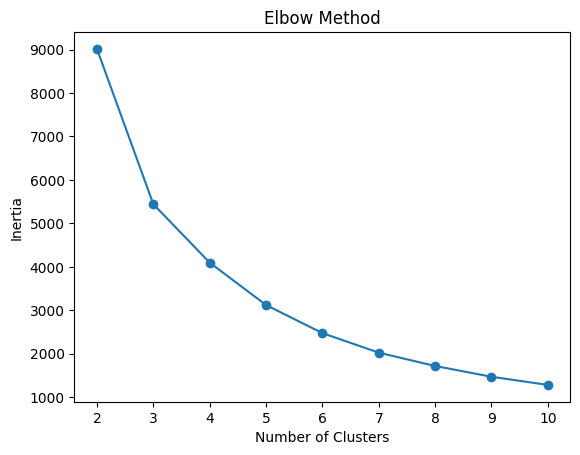

In [ ]:
# Find suitable number of clusters
inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

# Plot Elbow Curve
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

##Apply K-Means

In [ ]:
# Apply K-Means clustering
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


##Silhouette Score

In [ ]:
# Evaluate clustering quality
score = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.616


##View Customer Segments

In [ ]:
# Count customers in each cluster
print(rfm["Cluster"].value_counts().sort_index())

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


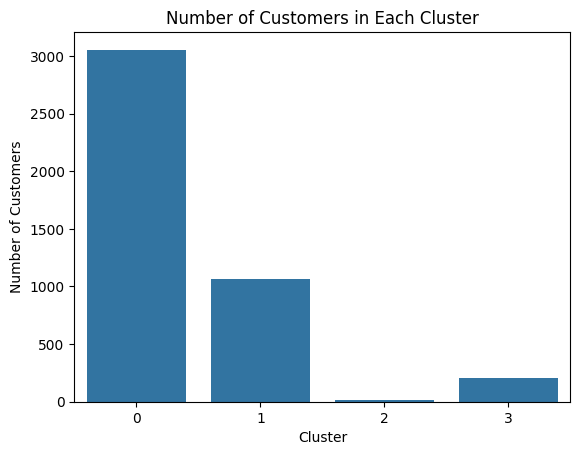

In [ ]:
# Visualize number of customers in each cluster
sns.countplot(x="Cluster", data=rfm)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

##Understand Each Cluster

In [ ]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


##PCA Visualization

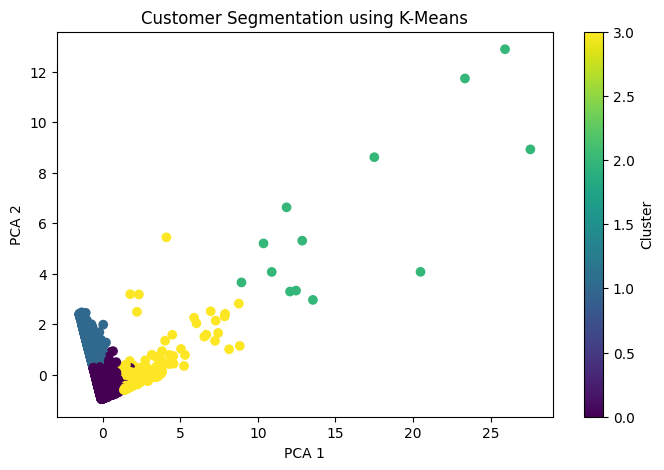

In [ ]:
from sklearn.decomposition import PCA

# Convert 3 RFM features into 2 dimensions
pca = PCA(n_components=2)
rfm_2d = pca.fit_transform(rfm_scaled)

# Plot clusters
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm_2d[:, 0],
    rfm_2d[:, 1],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.show()

##Final Results

In [ ]:
print("========== FINAL RESULTS ==========")

print("Number of Customers:", len(rfm))
print("Number of Clusters:", k)
print("Silhouette Score:", round(score, 3))

print("\nCluster Profile:")
display(cluster_profile)

========== FINAL RESULTS ==========
Number of Customers: 4338
Number of Clusters: 4
Silhouette Score: 0.616

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50
